https://medium.com/@cdabakoglu/clustering-mall-customers-k-means-machine-learning-5c12d5cacbe

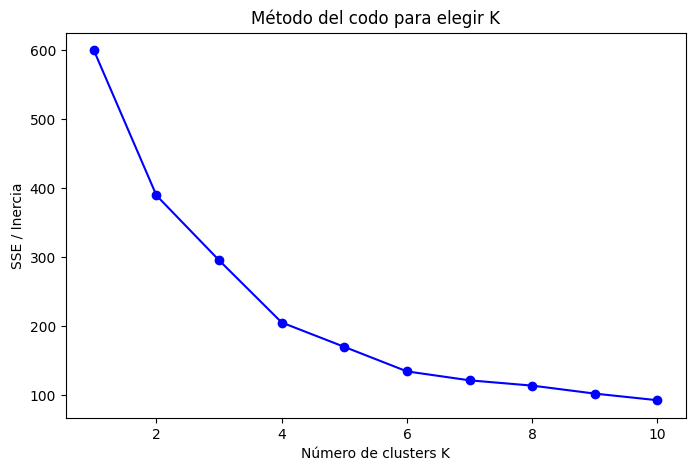

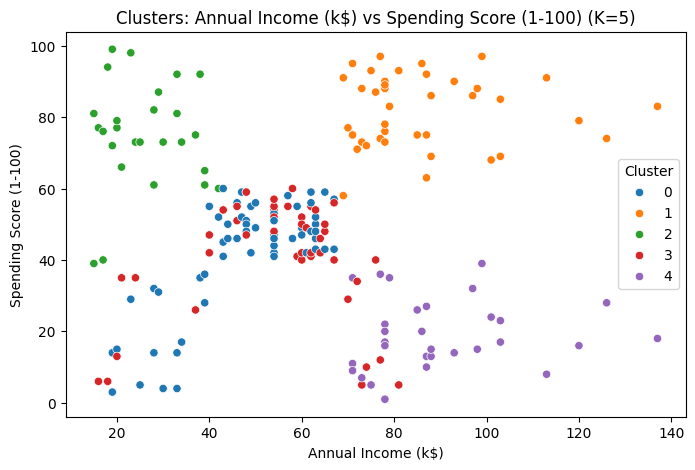

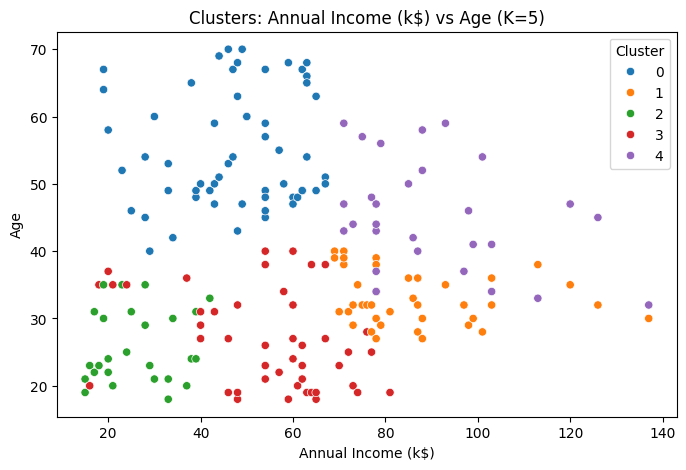

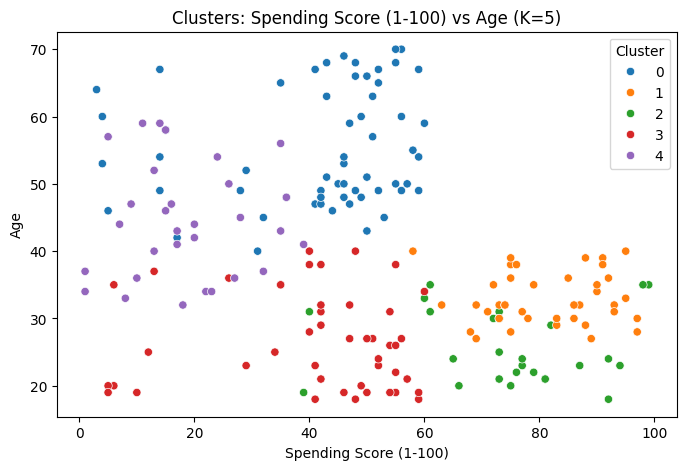

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargar los datos
df = pd.read_csv("Mall_Customers.csv")

# 2. Seleccionar las columnas relevantes
X = df[["Annual Income (k$)", "Spending Score (1-100)", "Age"]]

# 3. Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Método del codo
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# 5. Graficar el codo
plt.figure(figsize=(8,5))
plt.plot(K, sse, 'bo-')
plt.xlabel('Número de clusters K')
plt.ylabel('SSE / Inercia')
plt.title('Método del codo para elegir K')
plt.show()

# 6. Ajustar K-Means con el K elegido
k_optimo = 5
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels

# 7. Graficar todas las combinaciones de pares de variables
import itertools

vars = ["Annual Income (k$)", "Spending Score (1-100)", "Age"]

pairs = list(itertools.combinations(vars, 2))

for x_var, y_var in pairs:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x=x_var, y=y_var, hue="Cluster", palette="tab10")
    plt.title(f"Clusters: {x_var} vs {y_var} (K={k_optimo})")
    plt.show()